In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

Loading ..\Datastore\raw_captures\20260527T112810Z_groq_qwen3_32b_code_synthesis_942bdb61.pcap …


  2267 packets read.
[auto-detected local IP] 2606:4700:4409::ac40:9514  (use --src to override)
  Duration : 18.7s  |  Buckets: 2672
  Inbound  : 806 pkts  /  113 KB
  Outbound : 1395 pkts  /  682 KB


C:\Users\AS9Wa\AppData\Local\Temp\ipykernel_22336\1488043070.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


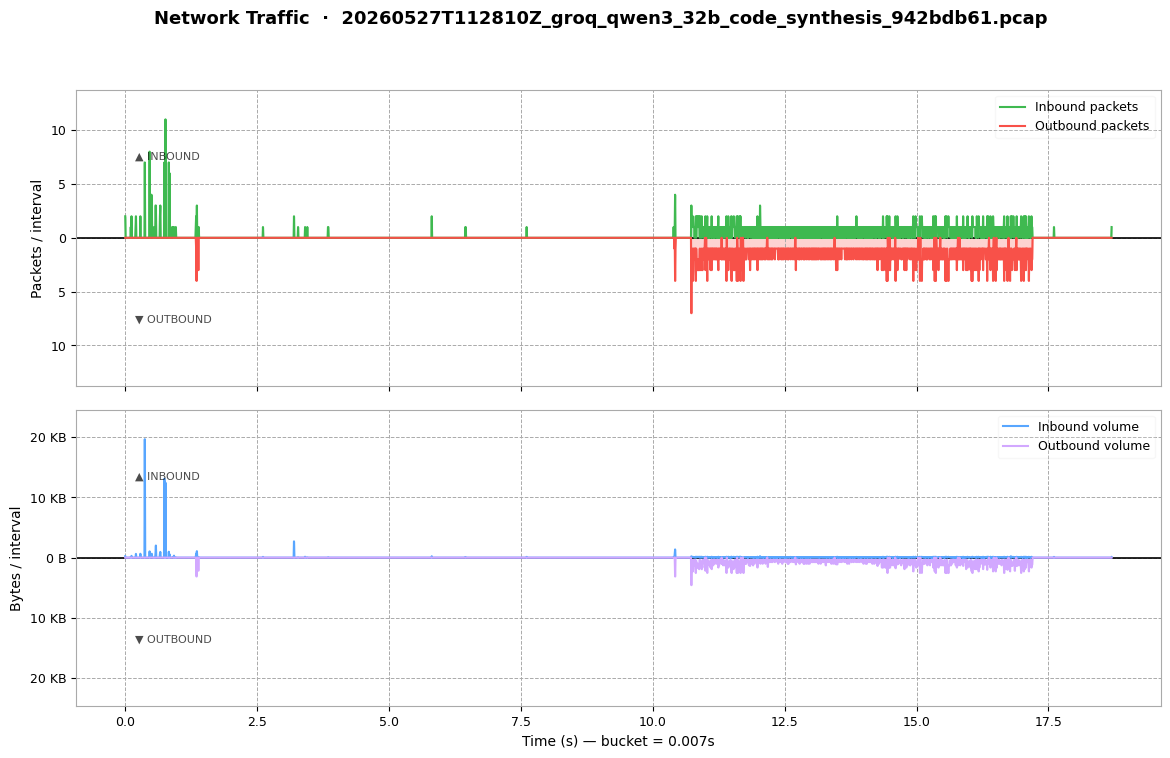

In [ ]:
"""
PCAP Traffic Visualizer
-----------------------
Plots inbound/outbound packet count and byte volume over time.
Positive Y = Inbound, Negative Y = Outbound.
 
Dependencies:
    pip install scapy matplotlib
"""
 
import sys
from collections import defaultdict
from pathlib import Path
 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
 
try:
    from scapy.all import rdpcap, IP, IPv6
except ImportError:
    sys.exit("scapy is not installed. Run:  pip install scapy")
 
 
# ── helpers ──────────────────────────────────────────────────────────────────
 
def guess_local_ip(packets):
    """Return the most frequent src IP as a proxy for 'this host'."""
    counts = defaultdict(int)
    for pkt in packets:
        if pkt.haslayer(IP):
            counts[pkt[IP].src] += 1
        elif pkt.haslayer(IPv6):
            counts[pkt[IPv6].src] += 1
    if not counts:
        sys.exit("No IP packets found in capture.")
    ip = max(counts, key=counts.get)
    print(f"[auto-detected local IP] {ip}  (use --src to override)")
    return ip
 
 
def bucket_traffic(packets, local_ip, interval):
    """
    Bin packets into time buckets.
    Returns (timestamps, in_pkts, out_pkts, in_bytes, out_bytes) as arrays.
    """
    if not packets:
        sys.exit("Capture is empty.")
 
    t0 = float(packets[0].time)
 
    in_pkts  = defaultdict(int)
    out_pkts = defaultdict(int)
    in_bytes  = defaultdict(int)
    out_bytes = defaultdict(int)
 
    for pkt in packets:
        if not (pkt.haslayer(IP) or pkt.haslayer(IPv6)):
            continue
 
        layer = IP if pkt.haslayer(IP) else IPv6
        src = pkt[layer].src
        size = len(pkt)
        t = int((float(pkt.time) - t0) / interval)
 
        if src == local_ip:          # outbound
            out_pkts[t]  += 1
            out_bytes[t] += size
        else:                         # inbound
            in_pkts[t]   += 1
            in_bytes[t]  += size
 
    max_t = max(
        max(in_pkts.keys(),  default=0),
        max(out_pkts.keys(), default=0),
    )
    times = np.arange(max_t + 1) * interval   # seconds from start
 
    ip  = np.array([in_pkts.get(i, 0)   for i in range(max_t + 1)], dtype=float)
    op  = np.array([out_pkts.get(i, 0)  for i in range(max_t + 1)], dtype=float)
    ib  = np.array([in_bytes.get(i, 0)  for i in range(max_t + 1)], dtype=float)
    ob  = np.array([out_bytes.get(i, 0) for i in range(max_t + 1)], dtype=float)
 
    return times, ip, op, ib, ob
 
 
def human_bytes(n, pos=None):
    for unit in ("B", "KB", "MB", "GB"):
        if abs(n) < 1024:
            return f"{n:.0f} {unit}"
        n /= 1024
    return f"{n:.1f} TB"
 
 
# ── plotting ──────────────────────────────────────────────────────────────────
 
DARK_BG   = "#ffffff"
GRID_COL  = "#aaaaaa"
IN_PKT    = "#3fb950"   # green  – inbound packets
OUT_PKT   = "#f85149"   # red    – outbound packets
IN_VOL    = "#58a6ff"   # blue   – inbound volume
OUT_VOL   = "#d2a8ff"   # purple – outbound volume
 
 
def plot(times, in_pkts, out_pkts, in_bytes, out_bytes, pcap_name, interval):
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"hspace": 0.08}
    )
    fig.patch.set_facecolor(DARK_BG)
 
    for ax in (ax1, ax2):
        ax.set_facecolor(DARK_BG)
        ax.spines[:].set_color(GRID_COL)
        ax.tick_params(colors="#000000", labelsize=9)
        ax.grid(axis="both", color=GRID_COL, linewidth=0.7, linestyle="--")
        ax.axhline(0, color="#000000", linewidth=1.2)
 
    # ── TOP: packet counts ────────────────────────────────────────────────
    ax1.fill_between(times,  in_pkts,  alpha=0.25, color=IN_PKT)
    ax1.fill_between(times, -out_pkts, alpha=0.25, color=OUT_PKT)
    ax1.plot(times,  in_pkts,  color=IN_PKT,  linewidth=1.5, label="Inbound packets")
    ax1.plot(times, -out_pkts, color=OUT_PKT, linewidth=1.5, label="Outbound packets")
 
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{abs(v):.0f}"))
    ax1.set_ylabel("Packets / interval", color="#000000", fontsize=10)
    ax1.legend(loc="upper right", framealpha=0.15, labelcolor="black",
               fontsize=9, facecolor=DARK_BG)
 
    # symmetric y axis for packets
    peak_p = max(in_pkts.max(), out_pkts.max(), 1)
    ax1.set_ylim(-peak_p * 1.25, peak_p * 1.25)
 
    # ── BOTTOM: byte volume ───────────────────────────────────────────────
    ax2.fill_between(times,  in_bytes,  alpha=0.25, color=IN_VOL)
    ax2.fill_between(times, -out_bytes, alpha=0.25, color=OUT_VOL)
    ax2.plot(times,  in_bytes,  color=IN_VOL,  linewidth=1.5, label="Inbound volume")
    ax2.plot(times, -out_bytes, color=OUT_VOL, linewidth=1.5, label="Outbound volume")
 
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: human_bytes(abs(v))))
    ax2.set_ylabel("Bytes / interval", color="#000000", fontsize=10)
    ax2.set_xlabel(f"Time (s) — bucket = {interval}s", color="#000000", fontsize=10)
    ax2.legend(loc="upper right", framealpha=0.15, labelcolor="black",
               fontsize=9, facecolor=DARK_BG)
 
    # symmetric y axis for bytes
    peak_b = max(in_bytes.max(), out_bytes.max(), 1)
    ax2.set_ylim(-peak_b * 1.25, peak_b * 1.25)
 
    # ── labels ────────────────────────────────────────────────────────────
    for ax in (ax1, ax2):
        mid = (ax.get_ylim()[1] * 0.55)
        ax.text(times[-1] * 0.01,  mid,       "▲ INBOUND",
                color="#000000", fontsize=8, va="center", alpha=0.7)
        ax.text(times[-1] * 0.01, -mid,       "▼ OUTBOUND",
                color="#000000", fontsize=8, va="center", alpha=0.7)
 
    title = f"Network Traffic  ·  {pcap_name}"
    fig.suptitle(title, color="black", fontsize=13, fontweight="bold", y=0.98)
 
    plt.tight_layout()
    plt.show()
 
 
# ── entry point ───────────────────────────────────────────────────────────────
 
def main():
    #traffic_path = Path("../Datastore/raw_captures/20260527T112810Z_groq_qwen3_32b_code_synthesis_942bdb61.pcap")
    traffic_path = Path("../Datastore/processed_datasets/filtered_pcaps/20260527T112810Z_groq_qwen3_32b_code_synthesis_942bdb61.pcap")
    interval = 0.007   # bucket width in seconds — adjust as needed
    local_ip = None  # set to e.g. "192.168.1.42" to override auto-detection
 
    if not traffic_path.exists():
        sys.exit(f"File not found: {traffic_path}")
 
    print(f"Loading {traffic_path} …")
    packets = rdpcap(str(traffic_path))
    print(f"  {len(packets)} packets read.")
 
    resolved_ip = local_ip or guess_local_ip(packets)
    times, ip, op, ib, ob = bucket_traffic(packets, resolved_ip, interval)
 
    print(f"  Duration : {times[-1]:.1f}s  |  Buckets: {len(times)}")
    print(f"  Inbound  : {int(ip.sum())} pkts  /  {human_bytes(ib.sum())}")
    print(f"  Outbound : {int(op.sum())} pkts  /  {human_bytes(ob.sum())}")
 
    plot(times, ip, op, ib, ob, traffic_path.name, interval)
 
 
if __name__ == "__main__":
    main()


Loading ..\Datastore\processed_datasets\filtered_pcaps\20260527T112810Z_groq_qwen3_32b_code_synthesis_942bdb61.pcap …
  2198 packets read.
[auto-detected local IP] 2606:4700:4409::ac40:9514  (use --src to override)
  Duration : 17.6s  |  Buckets: 2516
  Inbound  : 803 pkts  /  113 KB
  Outbound : 1395 pkts  /  682 KB


C:\Users\AS9Wa\AppData\Local\Temp\ipykernel_22336\1488043070.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


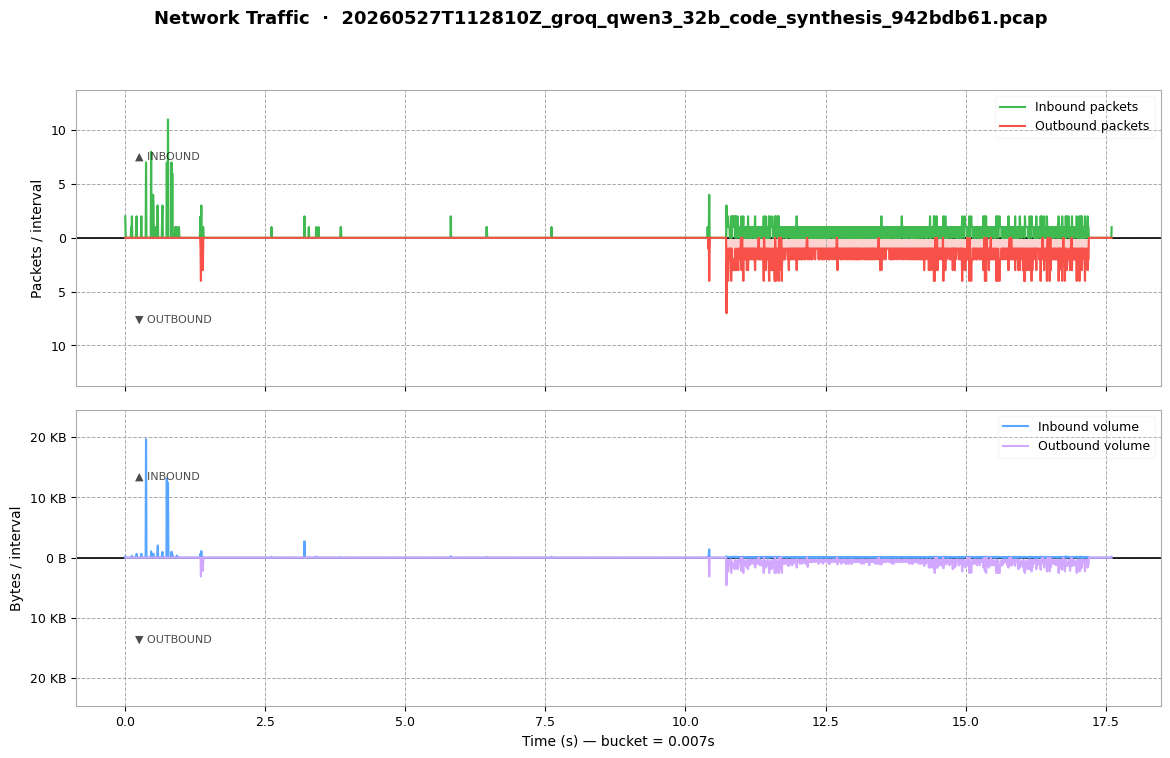

In [19]:
def main():
    #traffic_path = Path("../Datastore/raw_captures/20260527T112810Z_groq_qwen3_32b_code_synthesis_942bdb61.pcap")
    traffic_path = Path("../Datastore/processed_datasets/filtered_pcaps/20260527T112810Z_groq_qwen3_32b_code_synthesis_942bdb61.pcap")
    interval = 0.007   # bucket width in seconds — adjust as needed
    local_ip = None  # set to e.g. "192.168.1.42" to override auto-detection
 
    if not traffic_path.exists():
        sys.exit(f"File not found: {traffic_path}")
 
    print(f"Loading {traffic_path} …")
    packets = rdpcap(str(traffic_path))
    print(f"  {len(packets)} packets read.")
 
    resolved_ip = local_ip or guess_local_ip(packets)
    times, ip, op, ib, ob = bucket_traffic(packets, resolved_ip, interval)
 
    print(f"  Duration : {times[-1]:.1f}s  |  Buckets: {len(times)}")
    print(f"  Inbound  : {int(ip.sum())} pkts  /  {human_bytes(ib.sum())}")
    print(f"  Outbound : {int(op.sum())} pkts  /  {human_bytes(ob.sum())}")
 
    plot(times, ip, op, ib, ob, traffic_path.name, interval)
 
 
if __name__ == "__main__":
    main()